In [1]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import os

shap.initjs()

In [2]:
df = pd.read_csv("../data_clean.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,1,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,3,1
1,1,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,3,1
2,0,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,3,1
3,0,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,4,5
4,0,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,3,6


In [3]:
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]
print(X.shape)

(2087, 16)


In [4]:
model = joblib.load("../best_model.pkl")
model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [5]:
explainer = shap.Explainer(model)

shap_values = explainer(X)

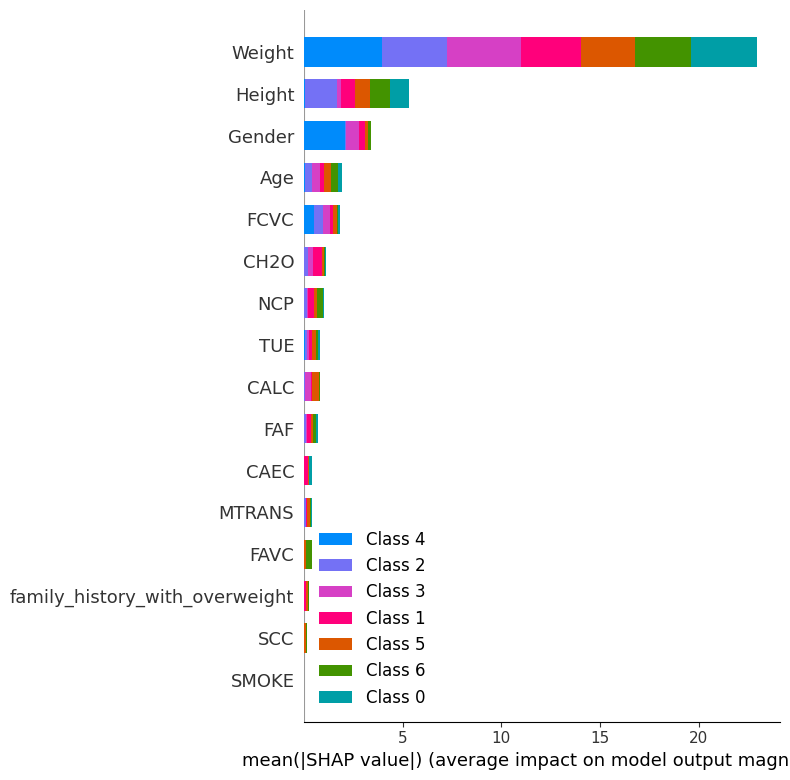

In [6]:
shap.summary_plot(shap_values, X)

In [7]:
X.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS'],
      dtype='object')

In [9]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

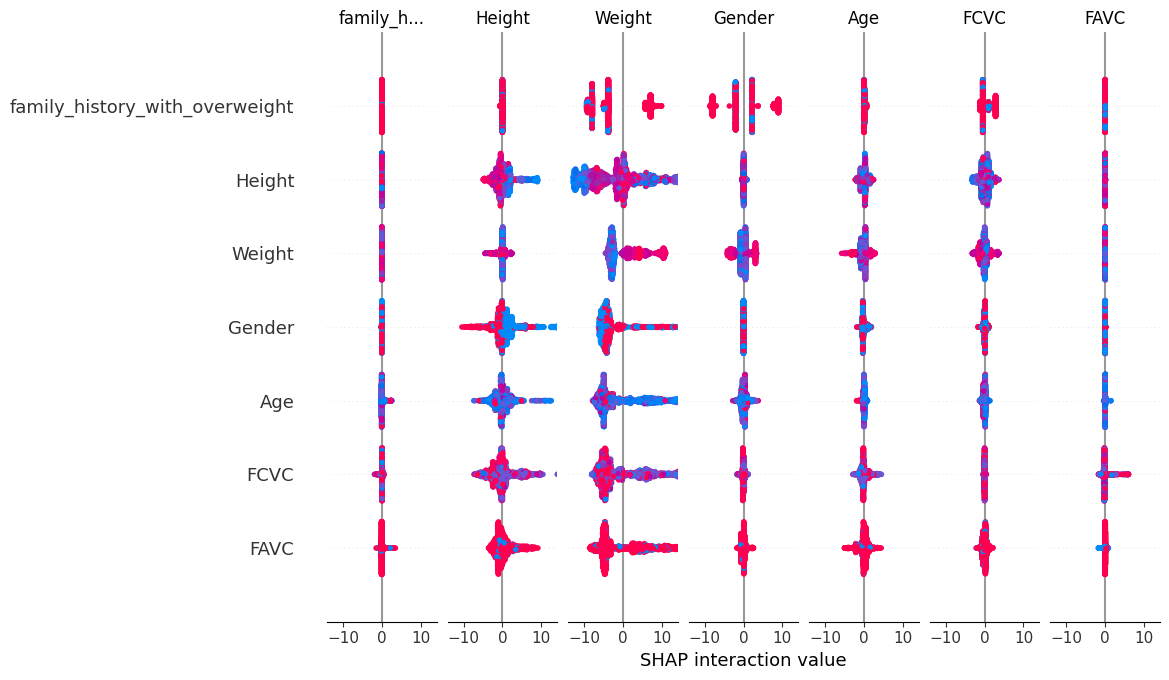

In [10]:
shap.summary_plot(shap_values, X)